# Unified window API

Consolidates the `_hull`-suffixed functions from notebook 09 into a single coherent API.
The three duplicated function families (`bivariate_k` / `bivariate_k_hull`,
`compute_envelope` / `compute_envelope_hull`, `run_pair_analysis` / `run_pair_analysis_hull`)
are replaced by unified versions that dispatch internally on window type:

- `window: tuple` → rectangular arc-fraction edge correction (original nb03 logic)
- `window: Shapely Polygon` → `fraction_inside_hull` Shapely intersection correction (nb09 logic)

`get_window(df, window_type, custom_path)` is the single point of control for window
type selection. Calling code passes the returned window object into the analysis
functions without needing to know which branch runs internally.

**Prerequisite:** Run `02c_fov_review_and_expansion.ipynb` first to produce
`data/processed/s1_expanded_strips_noise_flagged.parquet`.

## Imports

In [1]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from shapely.geometry import MultiPoint, Point, Polygon as ShapelyPolygon
import shapely

## Low-level building blocks

Copied verbatim from notebook 09. These are unchanged and serve as the foundation
for the polygon window path in the unified functions below.

In [2]:
def get_coords(df: pd.DataFrame,
               gene: str,
               x_col: str = 'x_global_px',
               y_col: str = 'y_global_px') -> np.ndarray:
    """Extract (N, 2) coordinate array for a given gene. Returns (0, 2) if absent."""
    coords = df.loc[df['target'] == gene, [x_col, y_col]].values
    return coords.astype(np.float64)

In [3]:
def k_to_l(k_vals: np.ndarray, r_vals: np.ndarray) -> np.ndarray:
    """Variance-stabilising transform: L(r) = sqrt(K(r)/pi) - r. Under CSR, L(r) = 0."""
    return np.sqrt(np.maximum(k_vals, 0) / np.pi) - r_vals

In [4]:
def get_convex_hull(df: pd.DataFrame,
                    x_col: str = 'x_global_px',
                    y_col: str = 'y_global_px'):
    """
    Compute the convex hull of all transcript coordinates in a strip DataFrame.

    Returns
    -------
    shapely.geometry.Polygon

    Raises
    ------
    ValueError
        If fewer than 3 points are present or all points are collinear.
    """
    coords = df[[x_col, y_col]].values.astype(np.float64)
    if len(coords) < 3:
        raise ValueError(
            f'Cannot compute convex hull: strip contains {len(coords)} point(s), '
            'minimum 3 required.'
        )
    hull = MultiPoint(coords).convex_hull
    if hull.geom_type != 'Polygon':
        raise ValueError(
            f'Convex hull is degenerate ({hull.geom_type}): all {len(coords)} '
            'points are collinear.'
        )
    return hull

In [5]:
def fraction_inside_hull(point, r, hull, resolution: int = 64):
    """
    Fraction of a disc of radius r centred at point that lies inside hull.

    Used as the per-point edge-correction weight in the polygon path of
    bivariate_k(). Approximated via Shapely polygon intersection.

    Parameters
    ----------
    point : tuple of float — (x, y)
    r : float
    hull : shapely.geometry.Polygon
    resolution : int
        Segments per quarter-circle for the disc approximation. Default 64.

    Returns
    -------
    float in (0, 1]
    """
    disc = Point(point).buffer(r, resolution=resolution)
    if hull.contains(disc):
        return 1.0
    intersection = hull.intersection(disc)
    return intersection.area / disc.area

In [6]:
def sample_in_polygon(polygon, n: int, rng) -> np.ndarray:
    """Sample n points uniformly inside a convex polygon via rejection sampling."""
    minx, miny, maxx, maxy = polygon.bounds
    pts = []
    while len(pts) < n:
        candidates = np.column_stack([
            rng.uniform(minx, maxx, n * 2),
            rng.uniform(miny, maxy, n * 2),
        ])
        mask = shapely.contains_xy(polygon, candidates[:, 0], candidates[:, 1])
        pts.extend(candidates[mask].tolist())
    return np.array(pts[:n])

## Custom window loader

In [7]:
def load_custom_window(path: str):
    """
    Load a user-drawn polygon from a JSON file saved by draw_custom_window() in 09b.

    Parameters
    ----------
    path : str
        Path to JSON file with key 'vertices': list of [x, y] pairs.

    Returns
    -------
    shapely.geometry.Polygon
    """
    with open(path) as f:
        data = json.load(f)
    poly = ShapelyPolygon(data['vertices'])
    if not poly.is_valid:
        raise ValueError(f'Loaded polygon from {path} is not valid: {poly.geom_type}')
    return poly

## `get_window` — unified window factory

Single entry point for all window types. Returns a tuple for `'rect'` (backward-compatible
with nb03) or a Shapely Polygon for `'hull'` and `'custom'`. The downstream functions
(`bivariate_k`, `compute_envelope`, `run_pair_analysis`) dispatch on the Python type
of the returned object — no string flags are passed further down the call chain.

In [8]:
def get_window(df: pd.DataFrame,
               window_type: str = 'hull',
               custom_path: str = None,
               x_col: str = 'x_global_px',
               y_col: str = 'y_global_px'):
    """
    Return the observation window for a strip DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Strip-level transcript DataFrame.
    window_type : str
        'rect'   — returns (x_min, x_max, y_min, y_max) tuple
        'hull'   — returns Shapely Polygon (convex hull of all transcripts)
        'custom' — loads a polygon from custom_path (JSON saved by 09b)
    custom_path : str or None
        Required when window_type='custom'.
    x_col, y_col : str
        Coordinate column names.

    Returns
    -------
    tuple or shapely.geometry.Polygon
    """
    if window_type == 'rect':
        return (
            df[x_col].min(), df[x_col].max(),
            df[y_col].min(), df[y_col].max(),
        )
    elif window_type == 'hull':
        return get_convex_hull(df, x_col, y_col)
    elif window_type == 'custom':
        if custom_path is None:
            raise ValueError("custom_path must be provided when window_type='custom'")
        return load_custom_window(custom_path)
    else:
        raise ValueError(
            f"Unknown window_type: {window_type!r}. Use 'rect', 'hull', or 'custom'."
        )

## `bivariate_k` — unified K-function

Dispatches on window type:
- `tuple` — rectangular isotropic arc-fraction correction (nb03 logic)
- `Shapely Polygon` — per-point Shapely disc intersection correction (nb09 logic)

The `_hull`-suffixed variant from nb09 is eliminated; its logic lives here.

In [9]:
def bivariate_k(coords_a: np.ndarray,
                coords_b: np.ndarray,
                r_vals: np.ndarray,
                window,
                resolution: int = 64) -> np.ndarray:
    """
    Bivariate (cross-type) Ripley's K-function K_AB(r).

    Dispatches on window type:
      tuple           -> rectangular isotropic arc-fraction edge correction
      Shapely Polygon -> Shapely disc-intersection edge correction

    Under CSR, K_AB(r) = pi * r^2.

    Parameters
    ----------
    coords_a : np.ndarray, shape (n_a, 2)
    coords_b : np.ndarray, shape (n_b, 2)
    r_vals : np.ndarray, shape (n_r,)
    window : tuple or shapely.geometry.Polygon
    resolution : int
        Disc approximation resolution for the polygon path. Ignored for tuple windows.

    Returns
    -------
    np.ndarray, shape (n_r,)
    """
    n_a = len(coords_a)
    n_b = len(coords_b)

    # --- Area and intensity ---
    if isinstance(window, tuple):
        x_min, x_max, y_min, y_max = window
        area = (x_max - x_min) * (y_max - y_min)
    else:
        area = window.area   # hull or custom polygon
    lambda_b = n_b / area

    tree_b = cKDTree(coords_b)
    r_max = r_vals[-1]
    neighbours = tree_b.query_ball_point(coords_a, r_max)

    k_vals = np.zeros(len(r_vals))

    for idx_a in range(n_a):
        x_i, y_i = coords_a[idx_a]
        b_indices = neighbours[idx_a]
        if len(b_indices) == 0:
            continue

        b_pts = coords_b[b_indices]
        dists = np.sqrt(((b_pts - coords_a[idx_a]) ** 2).sum(axis=1))

        if isinstance(window, tuple):
            # --- Rectangular path: arc-fraction edge correction ---
            dx_left  = x_i - x_min
            dx_right = x_max - x_i
            dy_bot   = y_i - y_min
            dy_top   = y_max - y_i

            for d_ij in dists:
                if d_ij == 0:
                    continue
                angle_outside = 0.0
                for dist_to_edge in [dx_left, dx_right, dy_bot, dy_top]:
                    if dist_to_edge < d_ij:
                        angle_outside += 2.0 * np.arccos(
                            np.clip(dist_to_edge / d_ij, -1.0, 1.0)
                        )
                frac = max((2.0 * np.pi - angle_outside) / (2.0 * np.pi), 0.01)
                weight = 1.0 / frac
                for k, r in enumerate(r_vals):
                    if d_ij <= r:
                        k_vals[k] += weight

        else:
            # --- Polygon path: Shapely disc-intersection edge correction ---
            for d_ij in dists:
                if d_ij == 0:
                    continue
                frac = fraction_inside_hull(
                    (x_i, y_i), d_ij, window, resolution=resolution
                )
                frac = max(frac, 0.01)
                weight = 1.0 / frac
                for k, r in enumerate(r_vals):
                    if d_ij <= r:
                        k_vals[k] += weight

    k_vals /= (n_a * lambda_b)
    return k_vals

## `compute_envelope` — unified permutation envelope

In [10]:
def compute_envelope(coords_a: np.ndarray,
                     coords_b: np.ndarray,
                     r_vals: np.ndarray,
                     window,
                     n_sim: int = 99,
                     seed: int = 42,
                     resolution: int = 64) -> tuple:
    """
    Monte Carlo permutation envelope for the bivariate L-function.

    Null model: pool all transcript locations and permute gene labels.
    Window (tuple or Polygon) is held fixed — only labels are shuffled.

    Parameters
    ----------
    window : tuple or shapely.geometry.Polygon
        Passed through to bivariate_k; dispatch is handled there.
    n_sim : int
        99 simulations give pointwise alpha ~0.02.
    resolution : int
        Disc resolution for polygon path; ignored for tuple windows.

    Returns
    -------
    l_lo, l_hi : np.ndarray, shape (n_r,)
    """
    rng = np.random.default_rng(seed)
    n_a = len(coords_a)
    pooled = np.vstack([coords_a, coords_b])
    sim_l = np.zeros((n_sim, len(r_vals)))

    for s in range(n_sim):
        idx = rng.permutation(len(pooled))
        sim_a = pooled[idx[:n_a]]
        sim_b = pooled[idx[n_a:]]
        k_sim = bivariate_k(sim_a, sim_b, r_vals, window, resolution=resolution)
        sim_l[s] = k_to_l(k_sim, r_vals)

    return sim_l.min(axis=0), sim_l.max(axis=0)

## `plot_diagnostics` — window-aware scatter plot

In [11]:
def plot_diagnostics(coords_a: np.ndarray,
                     coords_b: np.ndarray,
                     window,
                     gene_a: str = 'Gene A',
                     gene_b: str = 'Gene B',
                     title: str = '',
                     ax=None) -> None:
    """
    Scatter plot of two transcript patterns with window overlay.

    Handles both tuple (rectangular) and Shapely Polygon windows.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(coords_a[:, 0], coords_a[:, 1],
               s=8, alpha=0.6, color='steelblue',
               label=f'{gene_a} (n={len(coords_a)})')
    ax.scatter(coords_b[:, 0], coords_b[:, 1],
               s=8, alpha=0.6, color='tomato',
               label=f'{gene_b} (n={len(coords_b)})')

    if isinstance(window, tuple):
        x_min, x_max, y_min, y_max = window
        rect = plt.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            linewidth=1.5, edgecolor='black', facecolor='none',
            linestyle='--', label='Window (rect)'
        )
        ax.add_patch(rect)
    else:
        hx, hy = window.exterior.xy
        ax.plot(hx, hy, color='black', lw=1.5, linestyle='--', label='Window')

    ax.set_xlabel('x_global_px')
    ax.set_ylabel('y_global_px')
    ax.set_title(title or f'{gene_a} \u00d7 {gene_b}')
    ax.legend(fontsize=7, markerscale=2, loc='lower right', framealpha=0.9)
    ax.set_aspect('equal')

## `run_pair_analysis` — unified pipeline wrapper

In [12]:
def run_pair_analysis(strip_df: pd.DataFrame,
                      gene_a: str,
                      gene_b: str,
                      r_vals: np.ndarray,
                      window_type: str = 'hull',
                      custom_path: str = None,
                      n_sim: int = 99,
                      seed: int = 42,
                      resolution: int = 64,
                      diagnostics: bool = False,
                      strip_name: str = '') -> dict:
    """
    Full bivariate co-localisation analysis for one gene pair in one strip.

    Single entry point for all window types. Replaces both run_pair_analysis()
    (nb03) and run_pair_analysis_hull() (nb09).

    Parameters
    ----------
    strip_df : pd.DataFrame
        Transcript DataFrame for a single strip. The window is computed from
        all transcripts in this DataFrame (all genes).
    gene_a, gene_b : str
    r_vals : np.ndarray
    window_type : str
        'rect', 'hull', or 'custom'. Default 'hull'.
    custom_path : str or None
        Required when window_type='custom'.
    n_sim : int
    seed : int
    resolution : int
        Disc resolution for polygon edge correction. Ignored for rect windows.
    diagnostics : bool
    strip_name : str

    Returns
    -------
    dict with keys:
        'coords_a', 'coords_b', 'window', 'k_obs', 'l_obs', 'l_lo', 'l_hi',
        'n_a', 'n_b'
    """
    coords_a = get_coords(strip_df, gene_a)
    coords_b = get_coords(strip_df, gene_b)
    window   = get_window(strip_df, window_type=window_type, custom_path=custom_path)

    n_a, n_b = len(coords_a), len(coords_b)

    if diagnostics:
        fig, ax = plt.subplots(figsize=(8, 6))
        plot_diagnostics(coords_a, coords_b, window,
                         gene_a=gene_a, gene_b=gene_b,
                         title=f'{gene_a} \u00d7 {gene_b} | {strip_name}',
                         ax=ax)
        plt.show()

    # Summary
    print(f'  {gene_a}: {n_a} transcripts')
    print(f'  {gene_b}: {n_b} transcripts')
    if isinstance(window, tuple):
        x_min, x_max, y_min, y_max = window
        narrow = min(x_max - x_min, y_max - y_min)
        print(f'  Window: rect, narrowest dim = {narrow:.0f} px')
    else:
        print(f'  Window: {window_type}, area = {window.area:.0f} px\u00b2')
    print(f'  R_MAX = {r_vals[-1]:.0f} px')

    # Observed K(r) and L(r)
    t0 = time.time()
    k_obs = bivariate_k(coords_a, coords_b, r_vals, window, resolution=resolution)
    l_obs = k_to_l(k_obs, r_vals)
    print(f'  Observed L(r) in {time.time() - t0:.1f}s')
    for r_check in [50, 100, 200]:
        idx = np.argmin(np.abs(r_vals - r_check))
        print(f'    L(r={r_check}): {l_obs[idx]:.2f}')

    # Permutation envelope
    t0 = time.time()
    l_lo, l_hi = compute_envelope(
        coords_a, coords_b, r_vals, window,
        n_sim=n_sim, seed=seed, resolution=resolution
    )
    print(f'  Envelope in {time.time() - t0:.1f}s')

    return {
        'coords_a': coords_a,
        'coords_b': coords_b,
        'window':   window,
        'k_obs':    k_obs,
        'l_obs':    l_obs,
        'l_lo':     l_lo,
        'l_hi':     l_hi,
        'n_a':      n_a,
        'n_b':      n_b,
    }

## Dispatch unit check

Verify that `get_window` returns the correct types and that the dispatch in
`bivariate_k` hits the expected path.

In [13]:
# Minimal synthetic strip DataFrame
_rng = np.random.default_rng(99)
_mock_df = pd.DataFrame({
    'x_global_px': _rng.uniform(0, 1000, 200),
    'y_global_px': _rng.uniform(0, 3000, 200),
    'target':      ['GENE_A'] * 100 + ['GENE_B'] * 100,
})

w_rect = get_window(_mock_df, window_type='rect')
w_hull = get_window(_mock_df, window_type='hull')

assert isinstance(w_rect, tuple),           f'rect: expected tuple, got {type(w_rect)}'
assert isinstance(w_hull, ShapelyPolygon),  f'hull: expected Polygon, got {type(w_hull)}'

print(f'rect window: {w_rect}')
print(f'hull window: {w_hull.geom_type}, area={w_hull.area:.0f} px\u00b2')
print('Dispatch check passed.')

rect window: (np.float64(0.33651938897161227), np.float64(999.6873091039064), np.float64(16.249489684368122), np.float64(2991.1905552060275))
hull window: Polygon, area=2852459 px²
Dispatch check passed.


## Data loading

Uses the expanded, noise-cleaned dataset from 02c. If this file does not yet exist,
run `02c_fov_review_and_expansion.ipynb` first.

In [14]:
all_strips = pd.read_parquet('../data/processed/s1_expanded_strips_noise_flagged.parquet')
print(f'Total transcripts loaded: {len(all_strips):,}')

all_strips_clean = all_strips[~all_strips['is_noise']].copy()
print(f'After noise removal:      {len(all_strips_clean):,} '
      f'({len(all_strips_clean)/len(all_strips)*100:.1f}% retained)')
print(f'FOVs: {sorted(all_strips_clean["fov"].unique())}')
print(f'Strips: {sorted(all_strips_clean["strip"].unique())}')

Total transcripts loaded: 702,873
After noise removal:      649,637 (92.4% retained)
FOVs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Strips: ['strip_1', 'strip_2', 'strip_3']


## Analysis parameters

In [15]:
R_MAX  = 250
N_R    = 50
N_SIM  = 99
SEED   = 42
STRIPS = ['strip_1', 'strip_2', 'strip_3']

STRIP_LABELS = {
    'strip_1': 'Strip 1 (control)',
    'strip_2': 'Strip 2 (infected)',
    'strip_3': 'Strip 3 (control)',
}
STRIP_COLORS = {
    'strip_1': 'lightblue',
    'strip_2': 'tomato',
    'strip_3': 'seagreen',
}

r_vals = np.linspace(0, R_MAX, N_R)

## Control verification — positive control KRT8 x KRT18

Re-runs with `window_type='hull'` to confirm the unified API gives the same
qualitative result as nb09 (observed L(r) above envelope in all three strips).

In [ ]:
# GENE_A = 'KRT8'
# GENE_B = 'KRT18'

# results_krt8_krt18 = {}
# for strip_name in STRIPS:
#     strip_df = all_strips_clean[all_strips_clean['strip'] == strip_name]
#     print(f'\n{strip_name} | {GENE_A} \u00d7 {GENE_B}')
#     results_krt8_krt18[strip_name] = run_pair_analysis(
#         strip_df, GENE_A, GENE_B, r_vals,
#         window_type='hull', n_sim=N_SIM, seed=SEED, strip_name=strip_name
#     )


strip_1 | KRT8 × KRT18
  KRT8: 1401 transcripts
  KRT18: 1811 transcripts
  Window: hull, area = 147772526 px²
  R_MAX = 250 px
  Observed L(r) in 2.1s
    L(r=50): 167.19
    L(r=100): 267.74
    L(r=200): 399.05
  Envelope in 219.2s

strip_2 | KRT8 × KRT18
  KRT8: 778 transcripts
  KRT18: 1088 transcripts
  Window: hull, area = 118916284 px²
  R_MAX = 250 px
  Observed L(r) in 0.7s
    L(r=50): 203.62
    L(r=100): 293.13
    L(r=200): 371.15
  Envelope in 70.3s

strip_3 | KRT8 × KRT18
  KRT8: 732 transcripts
  KRT18: 1028 transcripts
  Window: hull, area = 136451736 px²
  R_MAX = 250 px
  Observed L(r) in 0.6s
    L(r=50): 230.90
    L(r=100): 340.57
    L(r=200): 449.78
  Envelope in 64.2s


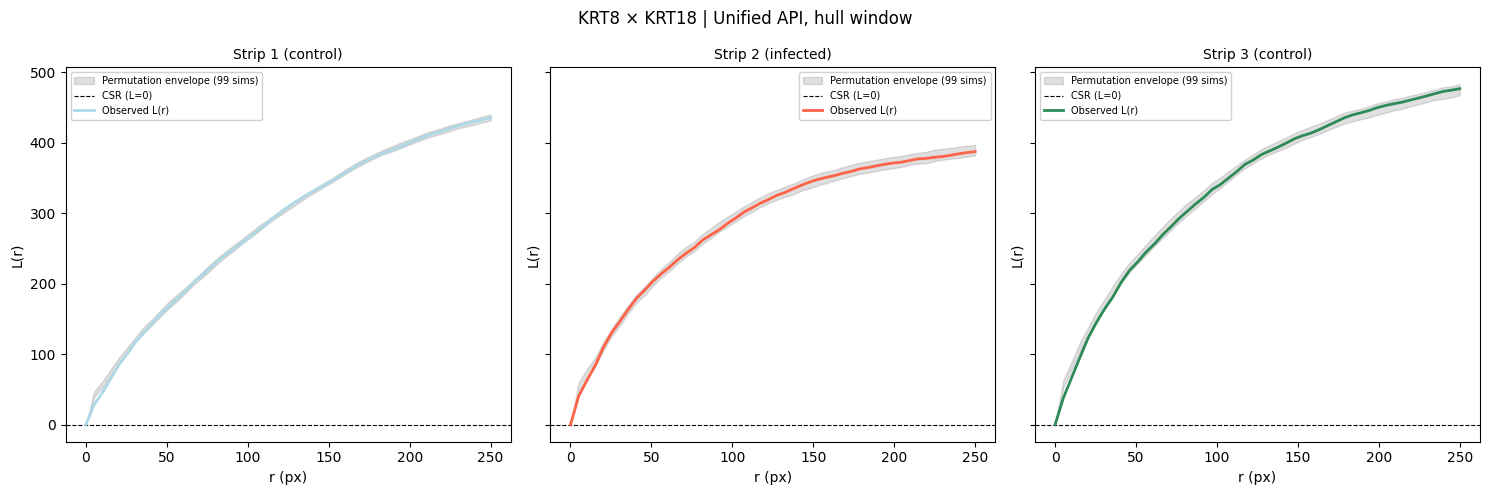

In [ ]:
# fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
# for ax, strip_name in zip(axes, STRIPS):
#     res = results_krt8_krt18[strip_name]
#     ax.fill_between(r_vals, res['l_lo'], res['l_hi'],
#                     alpha=0.25, color='grey', label='Permutation envelope (99 sims)')
#     ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='CSR (L=0)')
#     ax.plot(r_vals, res['l_obs'],
#             color=STRIP_COLORS[strip_name], linewidth=2, label='Observed L(r)')
#     ax.set_title(STRIP_LABELS[strip_name], fontsize=10)
#     ax.set_xlabel('r (px)')
#     ax.set_ylabel('L(r)')
#     ax.legend(fontsize=7, framealpha=0.9)
# fig.suptitle('KRT8 \u00d7 KRT18 | Unified API, hull window', fontsize=12)
# plt.tight_layout()
# plt.savefig('../results/figures/09a_KRT8_KRT18_hull.png', dpi=150)
# plt.show()

## Negative control: MALAT1 x KRT18

In [ ]:
# GENE_A = 'MALAT1'
# GENE_B = 'KRT18'

# results_malat1_krt18 = {}
# for strip_name in STRIPS:
#     strip_df = all_strips_clean[all_strips_clean['strip'] == strip_name]
#     print(f'\n{strip_name} | {GENE_A} \u00d7 {GENE_B}')
#     results_malat1_krt18[strip_name] = run_pair_analysis(
#         strip_df, GENE_A, GENE_B, r_vals,
#         window_type='hull', n_sim=N_SIM, seed=SEED, strip_name=strip_name
#     )


strip_1 | MALAT1 × KRT18
  MALAT1: 30189 transcripts
  KRT18: 1811 transcripts
  Window: hull, area = 147772526 px²
  R_MAX = 250 px
  Observed L(r) in 40.4s
    L(r=50): 170.58
    L(r=100): 267.08
    L(r=200): 396.51
  Envelope in 3951.8s

strip_2 | MALAT1 × KRT18
  MALAT1: 17989 transcripts
  KRT18: 1088 transcripts
  Window: hull, area = 118916284 px²
  R_MAX = 250 px
  Observed L(r) in 13.9s
    L(r=50): 198.93
    L(r=100): 292.24
    L(r=200): 373.43
  Envelope in 1596.5s

strip_3 | MALAT1 × KRT18
  MALAT1: 13610 transcripts
  KRT18: 1028 transcripts
  Window: hull, area = 136451736 px²
  R_MAX = 250 px
  Observed L(r) in 10.6s
    L(r=50): 228.69
    L(r=100): 335.19
    L(r=200): 437.64
  Envelope in 1129.7s


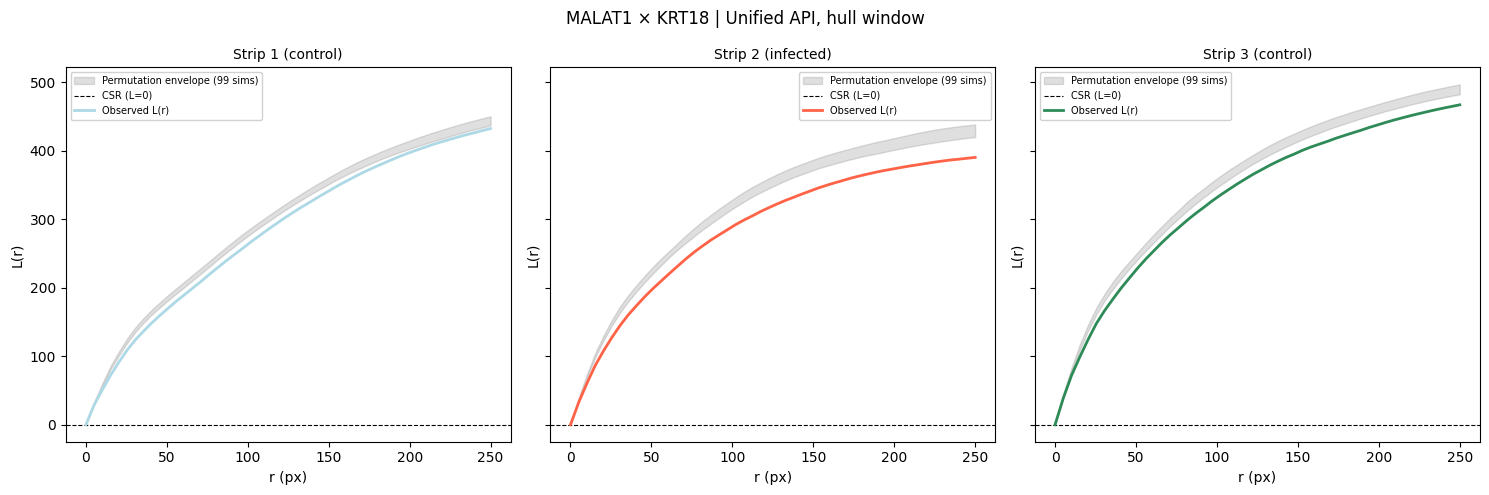

In [ ]:
# fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
# for ax, strip_name in zip(axes, STRIPS):
#     res = results_malat1_krt18[strip_name]
#     ax.fill_between(r_vals, res['l_lo'], res['l_hi'],
#                     alpha=0.25, color='grey', label='Permutation envelope (99 sims)')
#     ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='CSR (L=0)')
#     ax.plot(r_vals, res['l_obs'],
#             color=STRIP_COLORS[strip_name], linewidth=2, label='Observed L(r)')
#     ax.set_title(STRIP_LABELS[strip_name], fontsize=10)
#     ax.set_xlabel('r (px)')
#     ax.set_ylabel('L(r)')
#     ax.legend(fontsize=7, framealpha=0.9)
# fig.suptitle('MALAT1 \u00d7 KRT18 | Unified API, hull window', fontsize=12)
# plt.tight_layout()
# plt.savefig('../results/figures/09a_MALAT1_KRT18_hull.png', dpi=150)
# plt.show()

## Negative control: KRT8 x SCGB3A1

In [ ]:
# GENE_A = 'KRT8'
# GENE_B = 'SCGB3A1'

# results_krt8_scgb3a1 = {}
# for strip_name in STRIPS:
#     strip_df = all_strips_clean[all_strips_clean['strip'] == strip_name]
#     print(f'\n{strip_name} | {GENE_A} \u00d7 {GENE_B}')
#     results_krt8_scgb3a1[strip_name] = run_pair_analysis(
#         strip_df, GENE_A, GENE_B, r_vals,
#         window_type='hull', n_sim=N_SIM, seed=SEED, strip_name=strip_name
#     )


strip_1 | KRT8 × SCGB3A1
  KRT8: 1401 transcripts
  SCGB3A1: 1099 transcripts
  Window: hull, area = 147772526 px²
  R_MAX = 250 px
  Observed L(r) in 1.2s
    L(r=50): 160.32
    L(r=100): 271.36
    L(r=200): 393.29
  Envelope in 109.1s

strip_2 | KRT8 × SCGB3A1
  KRT8: 778 transcripts
  SCGB3A1: 1150 transcripts
  Window: hull, area = 118916284 px²
  R_MAX = 250 px
  Observed L(r) in 0.7s
    L(r=50): 204.34
    L(r=100): 307.09
    L(r=200): 386.37
  Envelope in 72.1s

strip_3 | KRT8 × SCGB3A1
  KRT8: 732 transcripts
  SCGB3A1: 919 transcripts
  Window: hull, area = 136451736 px²
  R_MAX = 250 px
  Observed L(r) in 0.5s
    L(r=50): 236.23
    L(r=100): 351.86
    L(r=200): 456.08
  Envelope in 53.6s


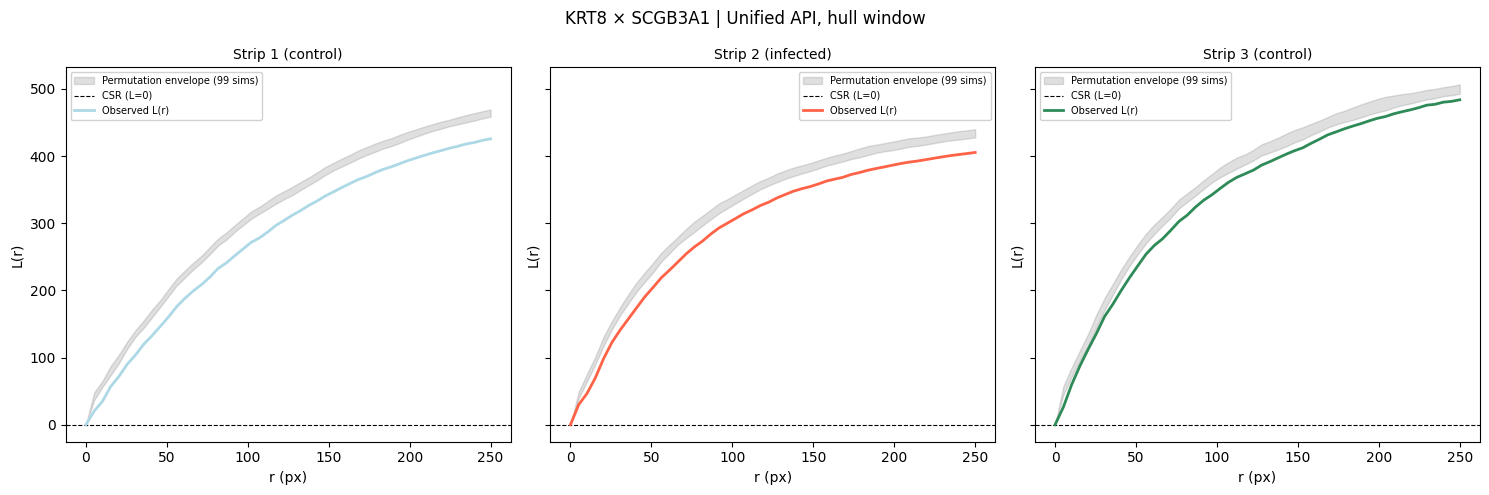

In [ ]:
# fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
# for ax, strip_name in zip(axes, STRIPS):
#     res = results_krt8_scgb3a1[strip_name]
#     ax.fill_between(r_vals, res['l_lo'], res['l_hi'],
#                     alpha=0.25, color='grey', label='Permutation envelope (99 sims)')
#     ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='CSR (L=0)')
#     ax.plot(r_vals, res['l_obs'],
#             color=STRIP_COLORS[strip_name], linewidth=2, label='Observed L(r)')
#     ax.set_title(STRIP_LABELS[strip_name], fontsize=10)
#     ax.set_xlabel('r (px)')
#     ax.set_ylabel('L(r)')
#     ax.legend(fontsize=7, framealpha=0.9)
# fig.suptitle('KRT8 \u00d7 SCGB3A1 | Unified API, hull window', fontsize=12)
# plt.tight_layout()
# plt.savefig('../results/figures/09a_KRT8_SCGB3A1_hull.png', dpi=150)
# plt.show()